## Gözetimsiz Öğrenme Genel Çalışma

Bu veri setinde Kaggle üzerinden aldığım Country Data Set üzerinde gözetimsiz öğrenme çalışmalarımı yaptım

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv("29-country_data.csv")

In [4]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [6]:
data.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [7]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols = 3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30)
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

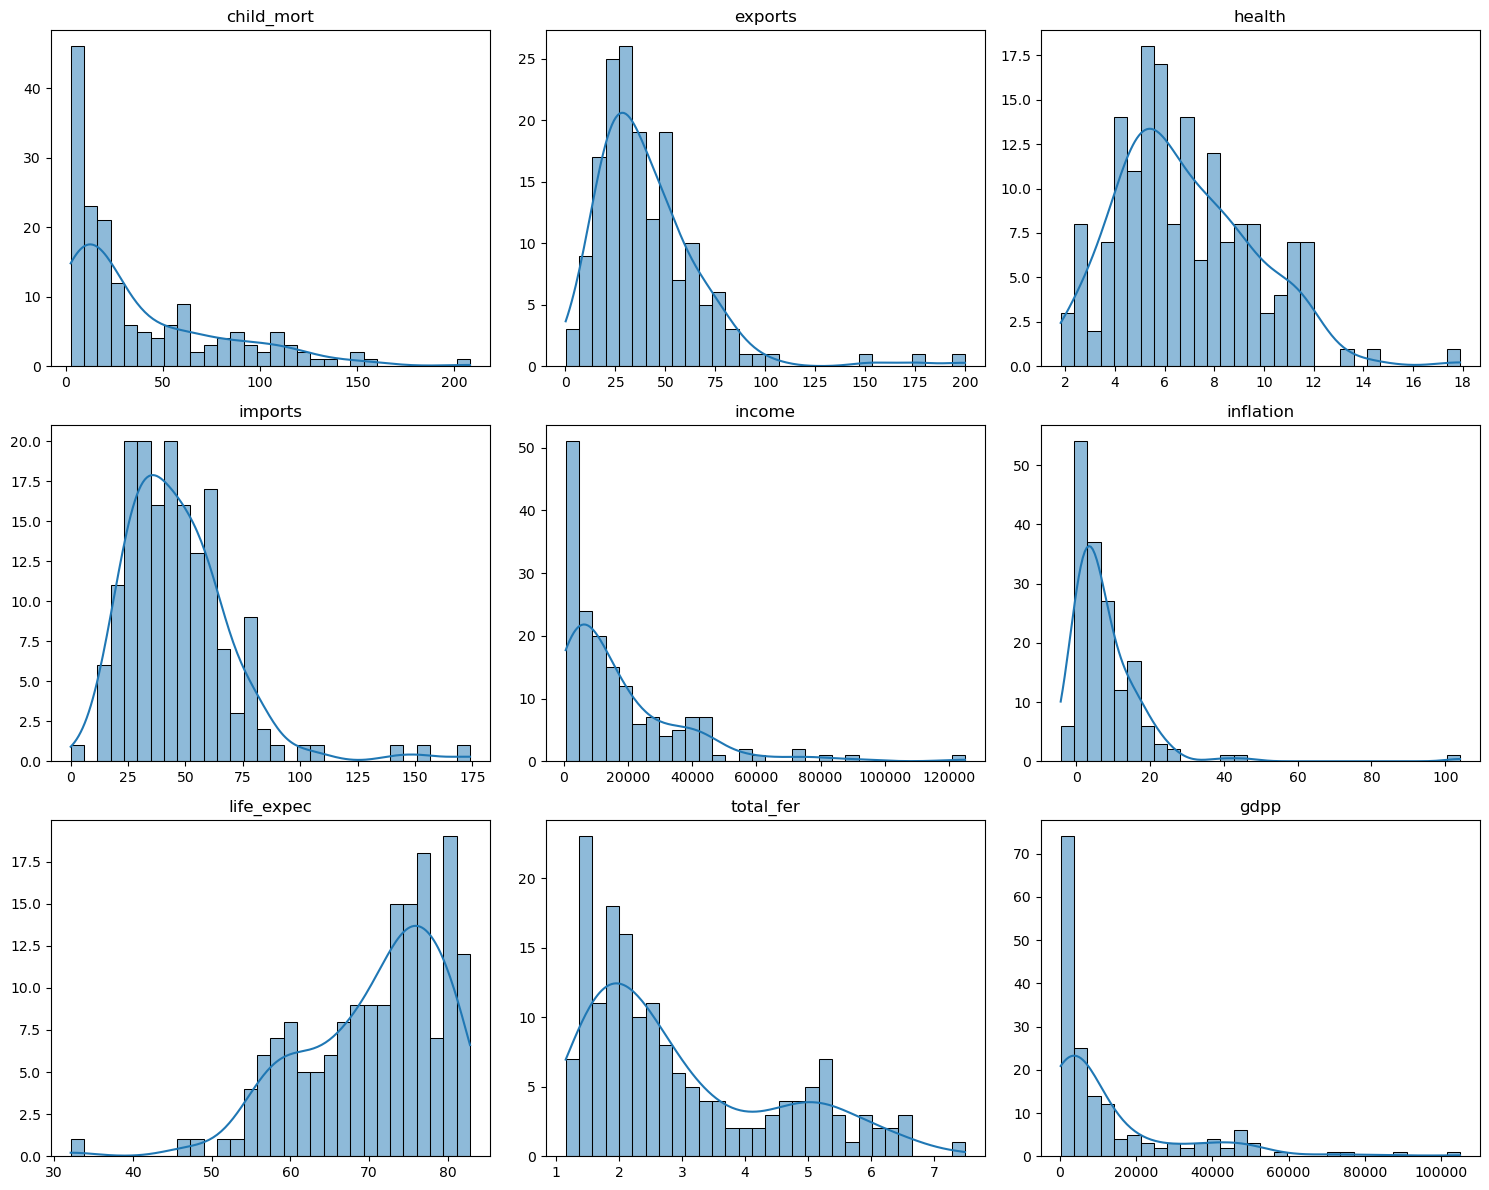

In [8]:
plot_all_histograms(data)

In [10]:
# Aralıklar birbirleriyle uyumlu değil.

In [11]:
# Sınıflandırmada ülke isimlerini kullanmamız gerekmiyor. En son kıyas için kullanabiliriz.

In [13]:
data2 = data.drop("country",axis=1)

In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
data2 = scaler.fit_transform(data2)

In [20]:
data.columns

Index(['country', 'child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'],
      dtype='object')

In [21]:
data2 = pd.DataFrame(data2,columns=['child_mort', 'exports', 'health', 'imports', 'income',
       'inflation', 'life_expec', 'total_fer', 'gdpp'])

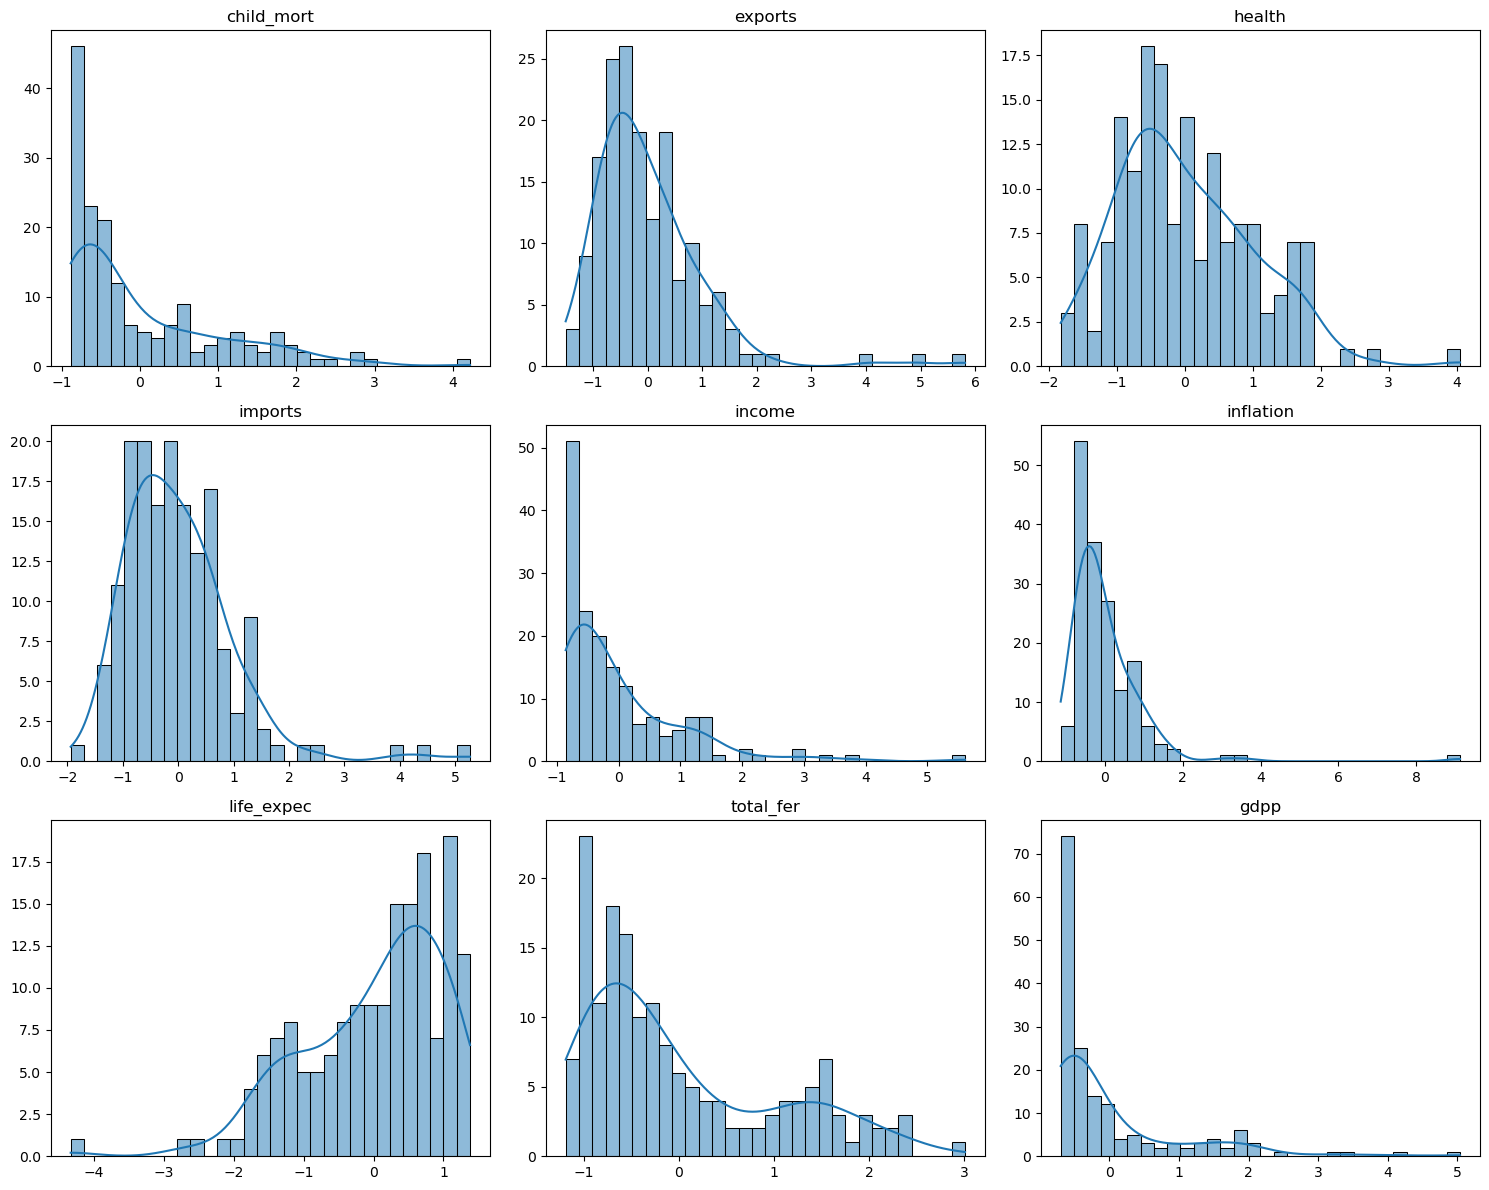

In [22]:
plot_all_histograms(data2)

In [23]:
# PCA yapmadan tüm kolonları kullanarak bir model oluşturmayı deneyeceğim.

In [24]:
import scipy.cluster.hierarchy as sch

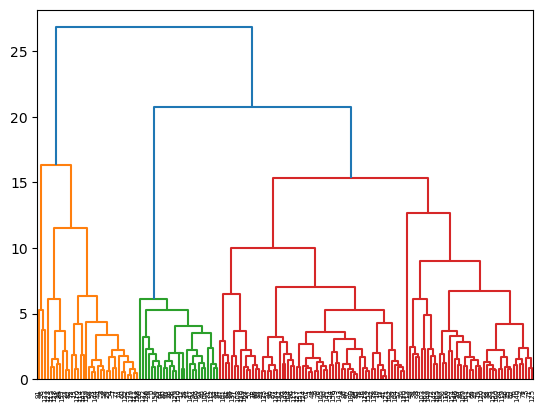

In [25]:
dendogram = sch.dendrogram(sch.linkage(data2,method="ward"))
plt.show()

In [26]:
# Dendogram'a göre 4 sınıf seçilebilir gibi görünüyor.

In [27]:
from sklearn.cluster import AgglomerativeClustering

In [28]:
hc = AgglomerativeClustering(n_clusters=4)

In [29]:
hc

,n_clusters,4
,metric,'euclidean'
,memory,None
,connectivity,None
,compute_full_tree,'auto'
,linkage,'ward'
,distance_threshold,None
,compute_distances,False


In [30]:
y_hc = hc.fit_predict(data2)

In [31]:
y_hc

array([2, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0,
       0, 1, 0, 2, 2, 0, 2, 1, 0, 2, 2, 0, 0, 0, 2, 2, 0, 0, 2, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 1, 0, 1, 0, 0, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 0, 3, 0, 2, 2, 0, 0, 2, 3, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       1, 1, 2, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 2, 0, 1, 2, 0, 0,
       2, 3, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 2, 0, 0, 2, 0, 0, 0,
       0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 2])

In [32]:
from sklearn.metrics import silhouette_score

In [36]:
print(silhouette_score(data2,y_hc))

0.24811891847692066


In [124]:
# Silhouette skoru -1 ile 1 arasında değer alır.
# Skorun pozitif ve yüksek olması, kümelerin birbirinden daha iyi ayrıldığını gösterir.
# Elde edilen skor çok yüksek değildir ancak veri setinde belirli bir küme yapısı olduğunu göstermektedir.

In [38]:
data["class"] = y_hc

In [39]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,0


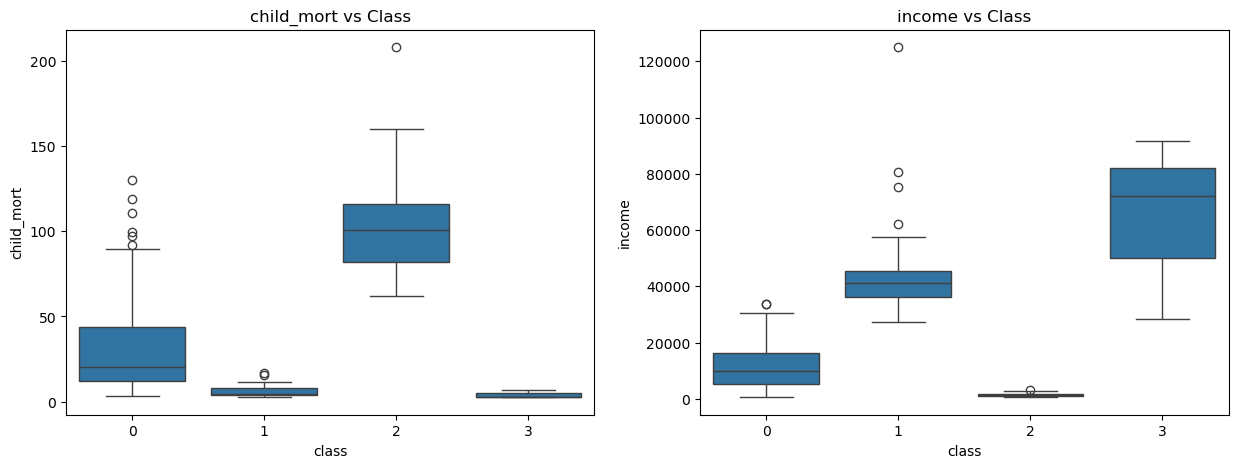

In [40]:
fig,ax = plt.subplots(nrows = 1, ncols= 2, figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=data, x="class",y="child_mort")
plt.title("child_mort vs Class")

plt.subplot(1,2,2)
sns.boxplot(data=data, x="class",y="income")
plt.title("income vs Class")

plt.show()

In [43]:
# Burada çeşitli yorumlamalar yapabiliriz.
# Mesela çocuk ölüm oranının düşüklüğü ve gelir miktarının yüksekliği bize az miktarda bütçe desteğine ihtiyacı olduğunu gösterir.

In [44]:
# Dendogram ile birlikte 4 sınıf seçmiştik fakat farklı sınıf sayısı seçildiğinde değişim nasıl oluyor onu inceleyeceğim.

In [46]:
cluster = [2,3,4,5,6]
for k in cluster:
   hc = AgglomerativeClustering(n_clusters=k)
   y_hc = hc.fit_predict(data2)
   print(silhouette_score(data2,y_hc))
   print("\n")

0.3153134331018189


0.24563001303300652


0.24811891847692066


0.21933015989396873


0.217674980548791




In [47]:
# DBSCAN ve HDBSCAN Uygulaması

In [48]:
#DBSCAN ve HDBSCAN'in çok doğru açıklayabileceğini düşünmüyorum fakat yine de pratik için yapmak istiyorum

In [49]:
from sklearn.cluster import DBSCAN

In [50]:
dbs = DBSCAN()

In [51]:
dbs.fit(data2)

,eps,0.5
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [52]:
dbs.labels_

array([-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])

In [125]:
# Tüm verileri aynı label'a atadı.
# DBSCAN, yoğunluk temelli bir kümeleme algoritmasıdır.
# Özellikle farklı şekillere sahip kümeleri ve aykırı değerleri tespit etmede kullanışlıdır.

In [54]:
# Günlük hayatta anomali bulma amacını gütmediğimiz veri setlerinde KMeans, Hierarchical kullanırız.

In [55]:
# KMEANS Denemesi

In [56]:
from sklearn.cluster import KMeans

In [57]:
# KMeans için cluster sayısını vermemiz gerekiyor.

In [58]:
# elbow method

In [60]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init="k-means++")
    kmeans.fit(data2)
    wcss.append(kmeans.inertia_)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows wi

In [61]:
wcss

[1503.0000000000002,
 1050.2145582853304,
 831.4428600464844,
 768.9096508047087,
 654.7707965800378,
 576.7466660777708,
 518.7295151094578,
 495.75347351930964,
 456.57524402289704,
 405.6909865791152]

In [62]:
# Kırılım 3 noktasında yavaşlıyor.

In [63]:
# Grafik üzerindende görebiliriz.

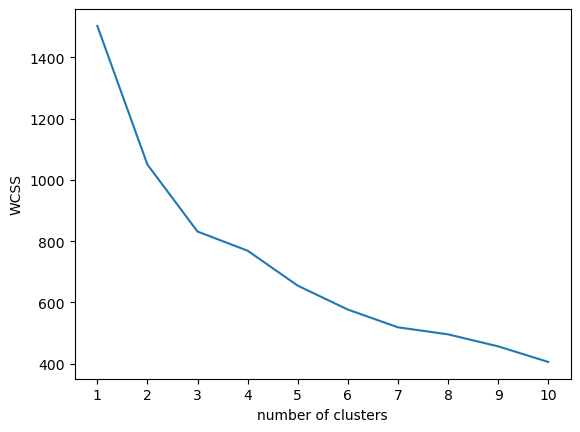

In [64]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel("WCSS")
plt.show()

In [66]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(data2)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [93]:
labels = kmeans.labels_

In [95]:
print(silhouette_score(data2,labels))

0.2904580253709216


In [120]:
# Hierarchical ile aşağı yukarı benzer sonuçlar aldık. 0-1 arası sonuçlar kümelerin ne kadar iyi ayrıştığını gösterir.

In [97]:
data["class"] = kmeans.labels_

In [98]:
data.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,class
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,1


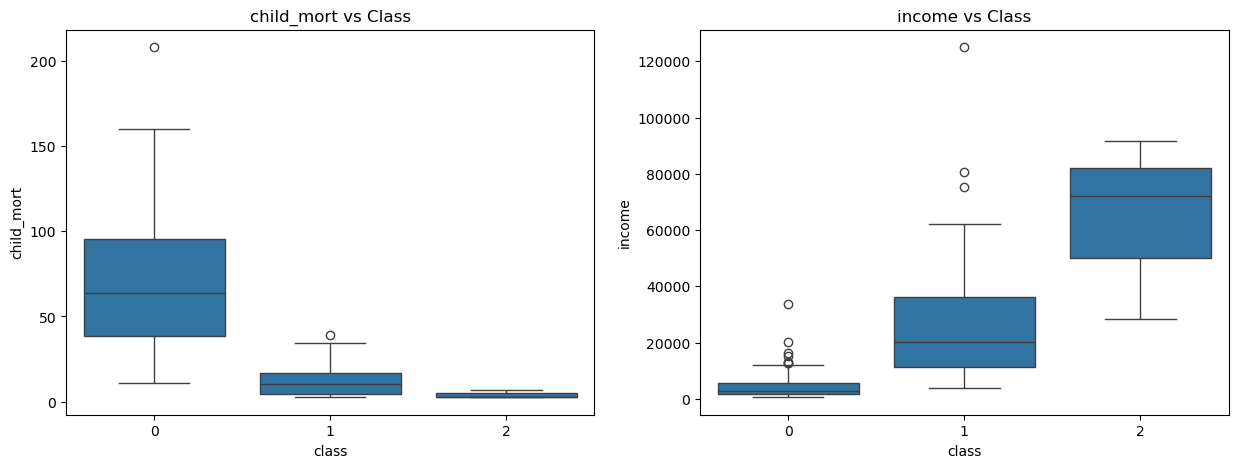

In [99]:
fig,ax = plt.subplots(nrows = 1, ncols= 2, figsize=(15,5))

plt.subplot(1,2,1)
sns.boxplot(data=data, x="class",y="child_mort")
plt.title("child_mort vs Class")

plt.subplot(1,2,2)
sns.boxplot(data=data, x="class",y="income")
plt.title("income vs Class")

plt.show()

In [100]:
# Bu şekilde daha açıklanabilir bir sonuca ulaştım.
# 0 - Ortalama Bütçe İhtiyacı
# 1 - Yüksek Bütçe İhtiyacı
# 2 - Düşük Bütçe İhtiyacı

In [101]:
# Tüm bu işlemleri PCA kullanmadan yaptım. Peki PCA kullanırsam sonuç nasıl değişir ?

In [102]:
from sklearn.decomposition import PCA

In [103]:
pca = PCA()

In [104]:
pca_data2 = pd.DataFrame(pca.fit_transform(data2))

In [105]:
pca_data2

,0,1,2,3,4,5,6,7,8
0,-2.913025,0.095621,-0.718118,1.005255,-0.158310,0.254597,-0.383000,-0.415076,0.014148
1,0.429911,-0.588156,-0.333486,-1.161059,0.174677,-0.084579,-0.248919,0.221042,-0.173316
2,-0.285225,-0.455174,1.221505,-0.868115,0.156475,0.401696,0.087214,0.184162,-0.084037
3,-2.932423,1.695555,1.525044,0.839625,-0.273209,0.547996,0.440835,0.355998,0.091339
4,1.033576,0.136659,-0.225721,-0.847063,-0.193007,0.206919,-0.241978,0.023681,-0.094270
...,...,...,...,...,...,...,...,...,...
162,-0.820631,0.639570,-0.389923,-0.706595,-0.395748,-0.009059,0.098738,-0.521886,0.497803
163,-0.551036,-1.233886,3.101350,-0.115311,2.082581,-0.097274,-0.206735,0.078805,0.275735
164,0.498524,1.390744,-0.238526,-1.074098,1.176081,-0.051607,0.143627,0.217590,0.036522
165,-1.887451,-0.109453,1.109752,0.056257,0.618365,0.540917,-0.060256,-0.089495,0.096049


In [106]:
# Şuan pca'in ilk aşamasını gerçekleştirdim fakat hala kolon sayımız azalmadı sadece kendi transform işlemini uyguladı.

In [107]:
# Yığılarak ilerleyen verilerden yola çıkarak doğru kolon sayısını bulabilirim.

In [108]:
pca.explained_variance_ratio_

array([0.4595174 , 0.17181626, 0.13004259, 0.11053162, 0.07340211,
       0.02484235, 0.0126043 , 0.00981282, 0.00743056])

In [109]:
# Burada 1 kolon için 0.4595174, 2 kolon için 0.4595174 + 0.17181626 şeklinde yığılarak ilerleme var.

In [123]:
# Belli bir kolon sayısı, verinin çoğunluğunu açıklayabildiğinden dolayı diğer kolonlara ihtiyacımız daha az.

In [111]:
pca_data2 = pca_data2.drop(columns = [3,4,5,6,7,8])

In [112]:
pca_data2

,0,1,2
0,-2.913025,0.095621,-0.718118
1,0.429911,-0.588156,-0.333486
2,-0.285225,-0.455174,1.221505
3,-2.932423,1.695555,1.525044
4,1.033576,0.136659,-0.225721
...,...,...,...
162,-0.820631,0.639570,-0.389923
163,-0.551036,-1.233886,3.101350
164,0.498524,1.390744,-0.238526
165,-1.887451,-0.109453,1.109752


In [113]:
# Bu şekilde 3 kolona indirmiş olduk.

In [114]:
# Aynı şekilde önceki adımları tekrar uygulayabilirim.

In [115]:
kmeans = KMeans(n_clusters=3)
kmeans.fit(pca_data2)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [116]:
labels = kmeans.labels_

In [117]:
silhouette_score(pca_data2,labels)

0.3724161232764184

In [122]:
# Evet PCA ile daha yüksek skor elde edebildim.
# PCA, varyansın büyük bölümünü koruyarak, daha verimli sonuçlar üretebilmemiz sağlar.
# Veri kaybı olduğu doğru fakat yüksek korelasyonlu anlamsız veriler bize çok şey kazandırmaz.